# Churn Prediction Modeling

This notebook trains and compares churn prediction models for the Career Growth Analytics MVP.

Key constraints:
- Features are computed only from events before the prediction cutoff (signup + 7 days).
- Labels are derived from user actions during days 8-21 after signup.
- Data is split chronologically: 60% train, 20% validation, 20% test.
- Model selection uses validation PR-AUC.
- The operating threshold is chosen on the validation set (F1 by default).

Interpretations in this notebook are associations captured by the model, not causal claims.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn import metrics
import sys

sys.path.insert(0, '../src')

from career_growth.decisions.next_best_action import recommend_next_action
from career_growth.features.model_features import prepare_model_matrix
from career_growth.modeling.evaluate import (
    compute_calibration_data,
    compute_confusion_matrix,
    compute_metrics,
)
from career_growth.modeling.explain import (
    build_global_explanation,
    explain_user_prediction,
)
from career_growth.modeling.nba_integration import generate_nba_examples
from career_growth.modeling.split import chronological_split
from career_growth.modeling.subgroup import evaluate_subgroups
from career_growth.modeling.train import train_and_select_model

%matplotlib inline

In [2]:
data_dir = Path('../data')
users = pd.read_csv(data_dir / 'sample' / 'users.csv')
events = pd.read_csv(data_dir / 'sample' / 'events.csv')
experiment_assignments = pd.read_csv(data_dir / 'sample' / 'experiment_assignments.csv')
labels = pd.read_csv(data_dir / 'processed' / 'labels.csv')

print(f"Users: {len(users):,}")
print(f"Events: {len(events):,}")
print(f"Churn rate: {labels['is_churned'].mean():.2%}")

Users: 1,000
Events: 17,856
Churn rate: 39.00%


## Feature Engineering

In [3]:
model_matrix = prepare_model_matrix(
    users, events, labels, experiment_assignments
)
print(f"Model matrix shape: {model_matrix.shape}")
print(f"Categorical features: {[c for c in model_matrix.columns if c not in {'user_id', 'signup_timestamp', 'is_churned'} and pd.api.types.is_object_dtype(model_matrix[c])]}")
print(f"Numeric features: {len([c for c in model_matrix.columns if pd.api.types.is_numeric_dtype(model_matrix[c])])}")

Model matrix shape: (1000, 40)
Categorical features: []
Numeric features: 30


## Chronological Split

In [4]:
train_df, val_df, test_df = chronological_split(
    model_matrix, train_frac=0.6, val_frac=0.2
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train churn rate: {train_df['is_churned'].mean():.2%}")
print(f"Val churn rate: {val_df['is_churned'].mean():.2%}")
print(f"Test churn rate: {test_df['is_churned'].mean():.2%}")

Train: 600 | Val: 200 | Test: 200
Train churn rate: 38.67%
Val churn rate: 38.00%
Test churn rate: 41.00%


## Train and Select Model

In [5]:
result = train_and_select_model(
    train_df, val_df, test_df, threshold_criterion="f1", random_state=42
)
print(f"Selected model: {result.model_name}")
print(f"Operating threshold: {result.threshold:.4f}")

print("\nCandidate validation metrics:")
for name, metrics_dict in result.candidate_validation_metrics.items():
    print(f"  {name}: PR-AUC={metrics_dict['pr_auc']:.4f}, ROC-AUC={metrics_dict['roc_auc']:.4f}, Brier={metrics_dict['brier_score']:.4f}")

print("\nValidation metrics:")
for k, v in result.val_metrics.items():
    print(f"  {k}: {v:.4f}")
print("\nTest metrics:")
for k, v in result.test_metrics.items():
    print(f"  {k}: {v:.4f}")

Selected model: hist_gradient_boosting
Operating threshold: 0.2900

Candidate validation metrics:
  logistic_regression: PR-AUC=0.5561, ROC-AUC=0.6793, Brier=0.2317
  hist_gradient_boosting: PR-AUC=0.5650, ROC-AUC=0.6555, Brier=0.2223

Validation metrics:
  pr_auc: 0.5650
  roc_auc: 0.6555
  log_loss: 0.6364
  brier_score: 0.2223
  threshold: 0.2900
  precision: 0.4688
  recall: 0.7895
  f1_score: 0.5882
  accuracy: 0.5800

Test metrics:
  pr_auc: 0.6328
  roc_auc: 0.7189
  log_loss: 0.6049
  brier_score: 0.2084
  threshold: 0.2900
  precision: 0.5188
  recall: 0.8415
  f1_score: 0.6419
  accuracy: 0.6150


## Confusion Matrix

In [6]:
confusion = compute_confusion_matrix(
    test_df["is_churned"].to_numpy(), result.test_probabilities, result.threshold
)
confusion_df = pd.DataFrame(
    [
        [confusion["true_negative"], confusion["false_positive"]],
        [confusion["false_negative"], confusion["true_positive"]],
    ],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)
display(confusion_df)

,Predicted 0,Predicted 1
Actual 0,54,64
Actual 1,13,69


## Precision-Recall, ROC, Calibration, and Risk Distribution

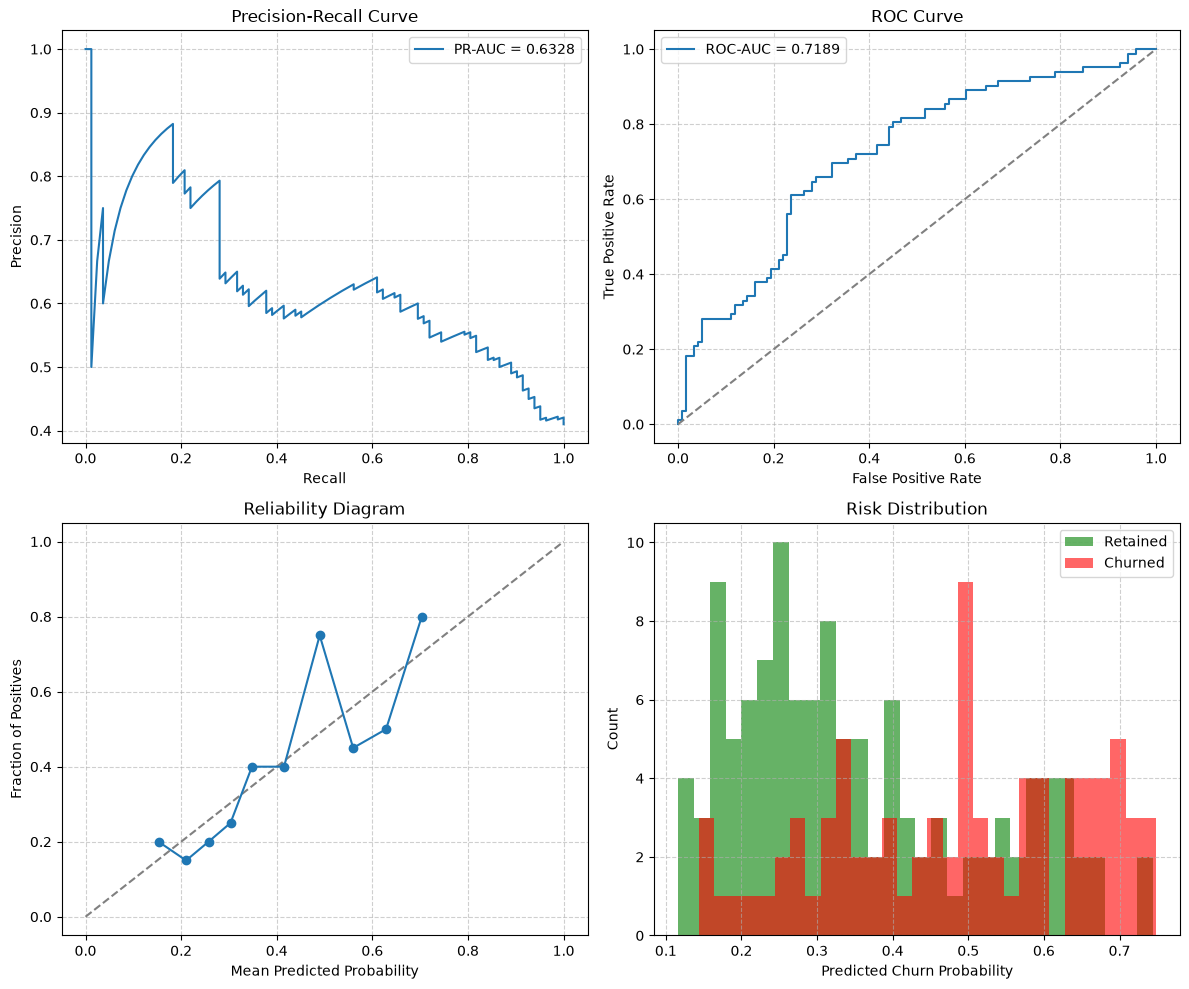

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
y_test = test_df["is_churned"].to_numpy()

precision, recall, _ = metrics.precision_recall_curve(y_test, result.test_probabilities)
axes[0, 0].plot(recall, precision, label=f"PR-AUC = {result.test_metrics['pr_auc']:.4f}")
axes[0, 0].set_xlabel("Recall")
axes[0, 0].set_ylabel("Precision")
axes[0, 0].set_title("Precision-Recall Curve")
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

fpr, tpr, _ = metrics.roc_curve(y_test, result.test_probabilities)
axes[0, 1].plot(fpr, tpr, label=f"ROC-AUC = {result.test_metrics['roc_auc']:.4f}")
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

calibration = compute_calibration_data(y_test, result.test_probabilities)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].plot(calibration["mean_predicted"], calibration["mean_observed"], marker="o")
axes[1, 0].set_xlabel("Mean Predicted Probability")
axes[1, 0].set_ylabel("Fraction of Positives")
axes[1, 0].set_title("Reliability Diagram")
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

axes[1, 1].hist(result.test_probabilities[y_test == 0], bins=30, alpha=0.6, label="Retained", color="green")
axes[1, 1].hist(result.test_probabilities[y_test == 1], bins=30, alpha=0.6, label="Churned", color="red")
axes[1, 1].set_xlabel("Predicted Churn Probability")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Risk Distribution")
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Global Explainability

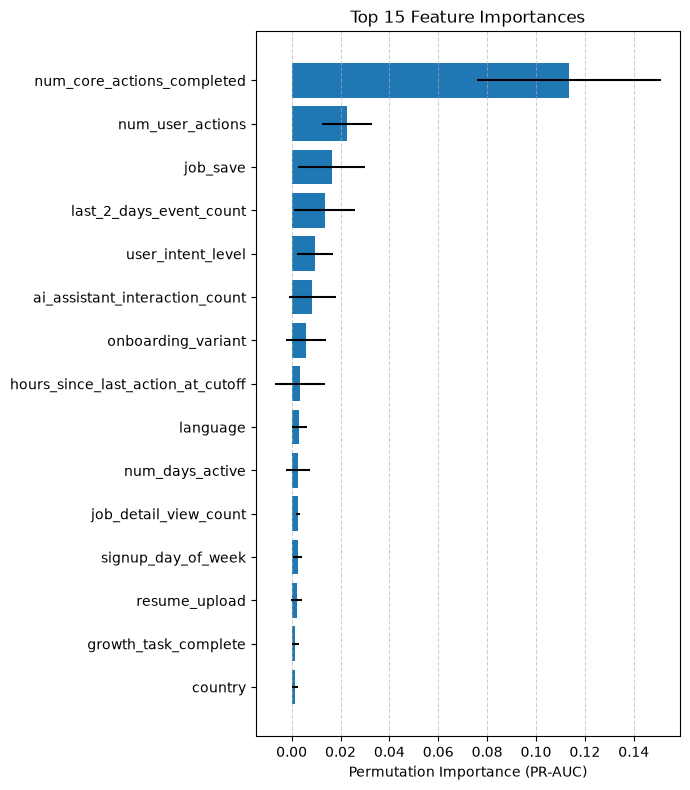

In [8]:
X_val = val_df[result.feature_columns]
global_explanation = build_global_explanation(
    result.model, X_val, val_df["is_churned"].to_numpy(), result.feature_columns, top_n=15
)

top_features = pd.DataFrame(global_explanation["permutation_importance"]).head(15)
fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(top_features["feature"][::-1], top_features["importance_mean"][::-1], xerr=top_features["importance_std"][::-1])
ax.set_xlabel("Permutation Importance (PR-AUC)")
ax.set_title("Top 15 Feature Importances")
ax.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Subgroup Performance

In [9]:
subgroup_df = evaluate_subgroups(test_df, result.test_probabilities, result.threshold)
display(subgroup_df)

,group_column,group_value,sample_size,churn_rate,precision,recall,f1_score,predicted_positive_rate,small_sample
0,acquisition_channel,campus_event,39,0.487179,0.666667,0.947368,0.782609,0.692308,True
1,acquisition_channel,content_marketing,23,0.304348,0.307692,0.571429,0.400000,0.565217,True
2,acquisition_channel,organic_search,75,0.440000,0.528302,0.848485,0.651163,0.706667,False
3,acquisition_channel,referral,19,0.210526,0.363636,1.000000,0.533333,0.578947,True
4,acquisition_channel,social_ads,44,0.431818,0.517241,0.789474,0.625000,0.659091,True
5,career_stage,early_career,51,0.470588,0.527778,0.791667,0.633333,0.705882,False
6,career_stage,new_graduate,63,0.380952,0.488372,0.875000,0.626866,0.682540,False
7,career_stage,student,86,0.395349,0.537037,0.852941,0.659091,0.627907,False
8,device_type,desktop,87,0.402299,0.508475,0.857143,0.638298,0.678161,False
9,device_type,mobile,80,0.412500,0.541667,0.787879,0.641975,0.600000,False


## User-Level Explanations

In [10]:
sample_users = test_df.sample(n=3, random_state=42).reset_index(drop=True)
for _, row in sample_users.iterrows():
    uid = row["user_id"]
    x_row = test_df[test_df["user_id"] == uid][result.feature_columns].iloc[[0]]
    explanation = explain_user_prediction(result.model, x_row, result.feature_columns, top_n=3)
    print(f"\nUser: {uid}")
    print(f"  Predicted risk: {explanation['predicted_risk']:.4f}")
    print(f"  Actual label: {row['is_churned']}")
    print(f"  Positive factors: {explanation['positive_factors']}")
    print(f"  Negative factors: {explanation['negative_factors']}")
    print("  Disclaimer: associations, not causal effects.")


User: 9556448f-dd87-5207-8bdf-7243ca57efde
  Predicted risk: 0.2928
  Actual label: 0
  Positive factors: [{'feature': 'num__avg_events_per_session', 'contribution': 0.065976}, {'feature': 'num__signup_hour', 'contribution': 0.055897}, {'feature': 'num__unique_event_type_count', 'contribution': 0.051857}]
  Negative factors: [{'feature': 'num__num_core_actions_completed', 'contribution': -0.32501}, {'feature': 'num__onboarding_started', 'contribution': -0.032799}, {'feature': 'num__job_save', 'contribution': -0.027219}]
  Disclaimer: associations, not causal effects.

User: 9d16a219-d8ec-566a-9568-34ad3079b681
  Predicted risk: 0.4907
  Actual label: 1
  Positive factors: [{'feature': 'num__max_events_in_session', 'contribution': 0.084555}, {'feature': 'cat__onboarding_variant_simplified', 'contribution': 0.072463}, {'feature': 'num__first_day_event_count', 'contribution': 0.043682}]
  Negative factors: [{'feature': 'num__avg_events_per_session', 'contribution': -0.048379}, {'feature'

## Next Best Action Examples

In [11]:
nba_examples = generate_nba_examples(
    result.model, test_df, users, events, result.feature_columns, result.threshold,
    n_examples=10, experiment_assignments=experiment_assignments
)
display(nba_examples)

,user_id,predicted_risk,predicted_class,action_name,channel,reason
0,7accd51b-5cc2-57d0-986c-14a0ea1d5337,0.311283,1,complete_onboarding,in_app,onboarding not completed
1,428387bf-1c71-542f-9d68-55b76fe22a02,0.549489,1,complete_onboarding,in_app,onboarding not completed
2,14be18d2-4bab-5761-b539-6eab4716ce7a,0.689683,1,complete_onboarding,in_app,onboarding not completed
3,c993aad0-c33b-5914-995c-8311b1dcb1cf,0.725795,1,send_reengagement_message,email,high churn risk with marketing consent
4,0fd3b4a7-6ae5-5bab-9b27-31bbfb22d08b,0.513230,1,complete_onboarding,in_app,onboarding not completed
5,2d6690b2-80f4-5417-b67c-68aa1bf58193,0.217692,0,complete_onboarding,in_app,onboarding not completed
6,a06708a1-545b-51d8-b968-7486973be4e0,0.205364,0,complete_growth_task,in_app,growth task not completed
7,7983a0f2-08f4-5ce5-bd52-8f9b6f9850aa,0.159746,0,complete_profile,in_app,profile not completed
8,49ec10f5-170b-5a00-97a6-0b5f146b017c,0.143537,0,upload_resume,in_app,resume not uploaded
9,b8a3df33-c2f5-59d3-b16b-97153b0619d5,0.167788,0,complete_onboarding,in_app,onboarding not completed


## Save Artifacts

In [12]:
artifact_dir = Path('../artifacts')
artifact_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(result.model, artifact_dir / "churn_model.joblib")

metadata = {
    "model_name": result.model_name,
    "threshold": result.threshold,
    "feature_columns": result.feature_columns,
    "val_metrics": result.val_metrics,
    "test_metrics": result.test_metrics,
    "candidate_validation_metrics": result.candidate_validation_metrics,
}
with open(artifact_dir / "notebook_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Artifacts saved to ../artifacts/")

Artifacts saved to ../artifacts/


## Limitations

- The data is synthetic; causal effects are calibrated for pipeline demonstration.
- Feature importances and user explanations are model associations, not causal drivers.
- Subgroup metrics for small groups (sample size < 50) should be interpreted with caution.
- This notebook is an MVP; production deployment requires real-data validation and governance.